In [1]:
# import important libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
import joblib

In [2]:
# import dataset
dataset = pd.read_csv("heart.csv")
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
# chesk dataset shape
dataset.shape

(1025, 14)

In [4]:
# check dataset null values
dataset.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
# check dataset duplicated values
dataset.duplicated().sum()

np.int64(723)

In [6]:
# dataset.drop_duplicates(inplace=True)

In [7]:
# dataset.duplicated().sum()

In [8]:
# check dataset descript
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# check dataset information
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


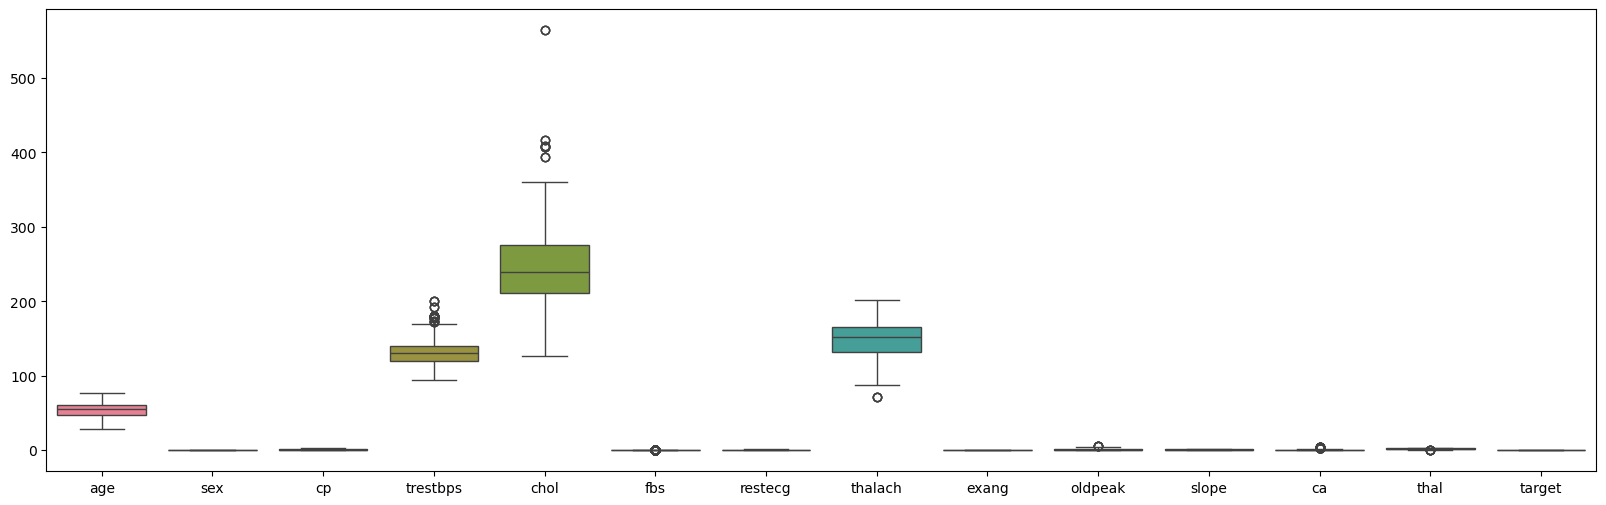

In [10]:
# chech outlier present or not
plt.figure(figsize=(20,6))
sns.boxplot(dataset)
plt.show()

In [11]:
# calculate mean and standard deviation for remove outlier
mn = dataset["chol"].mean()
std = dataset["chol"].std()
min_range = mn - (3 * std)
max_range = mn + (3 * std)

In [12]:
# get new dataset under minimum and maximum range
dataset = dataset[(dataset["chol"] > min_range) & (dataset["chol"] < max_range)]

In [13]:
# show new dataset
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


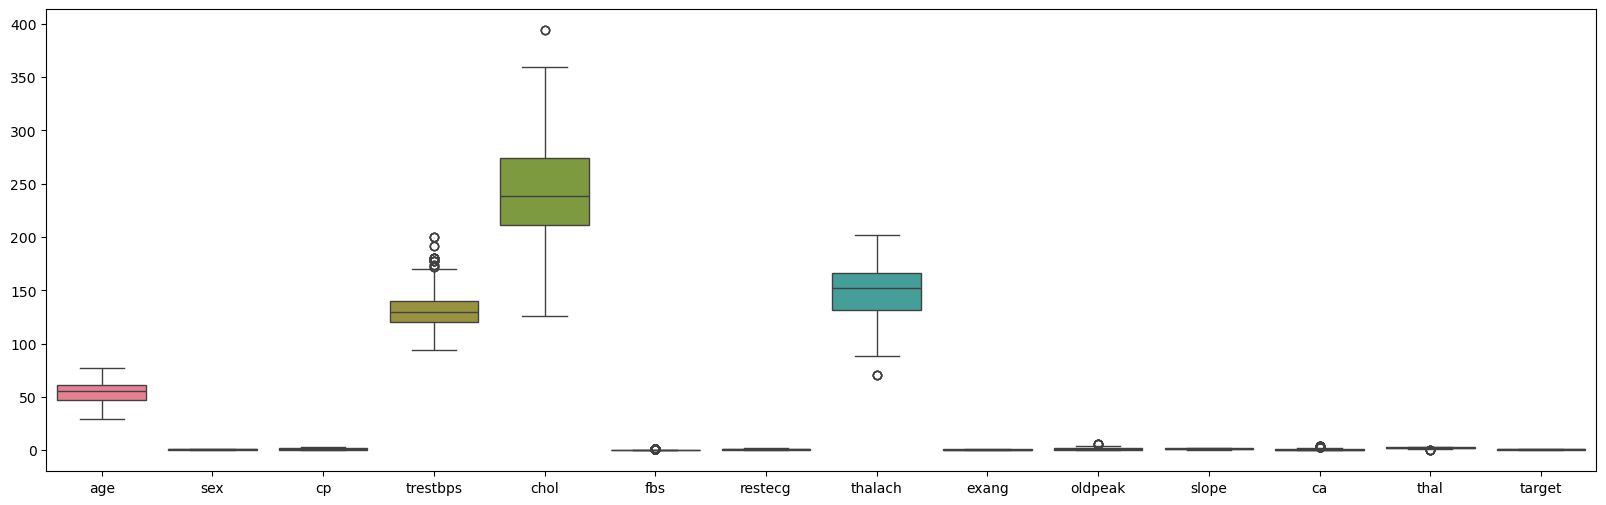

In [14]:
# chech outlier remove or not
plt.figure(figsize=(20,6))
sns.boxplot(dataset)
plt.show()

In [15]:
# sepearate dataset into independent and dependent
x = dataset.iloc[:,:-1]
y = dataset["target"]

In [16]:
#scaled data
sc = StandardScaler()
x_sc = sc.fit_transform(x)
x = pd.DataFrame(x_sc,columns=x.columns)
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.256709,0.647576,-0.915638,-0.373526,-0.682783,-0.417150,0.878476,0.819937,-0.714456,-0.048638,0.989230,1.227433,1.098955
1,-0.146395,0.647576,-0.915638,0.481052,-0.878293,2.397221,-1.017084,0.257846,1.399666,1.752147,-2.240126,-0.725652,1.098955
2,1.728945,0.647576,-0.915638,0.765912,-1.508270,-0.417150,0.878476,-1.039287,1.399666,1.323389,-2.240126,-0.725652,1.098955
3,0.736118,0.647576,-0.915638,0.936827,-0.878293,-0.417150,0.878476,0.517273,-0.714456,-0.906154,0.989230,0.250890,1.098955
4,0.846432,-1.544220,-0.915638,0.367108,1.098532,2.397221,0.878476,-1.860805,-0.714456,0.723127,-0.625448,2.203976,-0.512845
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,0.515490,0.647576,0.055668,0.481052,-0.487273,-0.417150,0.878476,0.646986,1.399666,-0.906154,0.989230,-0.725652,-0.512845
1008,0.625804,0.647576,-0.915638,-0.373526,0.316491,-0.417150,-1.017084,-0.347483,1.399666,1.494892,-0.625448,0.250890,1.098955
1009,-0.808280,0.647576,-0.915638,-1.228105,0.685788,-0.417150,-1.017084,-1.341952,1.399666,-0.048638,-0.625448,0.250890,-0.512845
1010,-0.477337,-1.544220,-0.915638,-1.228105,0.229598,-0.417150,-1.017084,0.430797,-0.714456,-0.906154,0.989230,-0.725652,-0.512845


In [17]:
# split data into train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
# choose multiple models for best get best model into them
models = {
    "LogisticRegression":LogisticRegression(),
    "SVC":SVC(probability=True),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(n_estimators=100)
}

In [19]:
# train each model
for name,model in models.items():
    model.fit(x_train,y_train)
    print(name,"trained")

LogisticRegression trained
SVC trained
Decision Tree trained
Random Forest trained


In [20]:
# chech each model score
for name,model in models.items():
    print("model:",name)
    y_pred = model.predict(x_test)
    y_pred_proba = model.predict_proba(x_test)[:,1]
    print("train_score:",model.score(x_train,y_train)*100)
    print("test_score:",model.score(x_test,y_test)*100)
    print("accuracy_score:",accuracy_score(y_test,y_pred)*100)
    print("recall_score:",recall_score(y_test,y_pred)*100)
    print("f1_score:",f1_score(y_test,y_pred)*100)
    print("roc_auc_score:",roc_auc_score(y_test,y_pred_proba)*100)
    print()

model: LogisticRegression
train_score: 86.27935723114956
test_score: 82.26600985221675
accuracy_score: 82.26600985221675
recall_score: 89.32038834951457
f1_score: 83.63636363636363
roc_auc_score: 90.73786407766991

model: SVC
train_score: 95.7972805933251
test_score: 92.61083743842364
accuracy_score: 92.61083743842364
recall_score: 93.20388349514563
f1_score: 92.7536231884058
roc_auc_score: 96.33009708737865

model: Decision Tree
train_score: 100.0
test_score: 100.0
accuracy_score: 100.0
recall_score: 100.0
f1_score: 100.0
roc_auc_score: 100.0

model: Random Forest
train_score: 100.0
test_score: 100.0
accuracy_score: 100.0
recall_score: 100.0
f1_score: 100.0
roc_auc_score: 100.0



In [21]:
# predict x_test using best model
y_pred = models["Decision Tree"].predict(x_test)

In [22]:
# see confusion matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[100,   0],
       [  0, 103]])

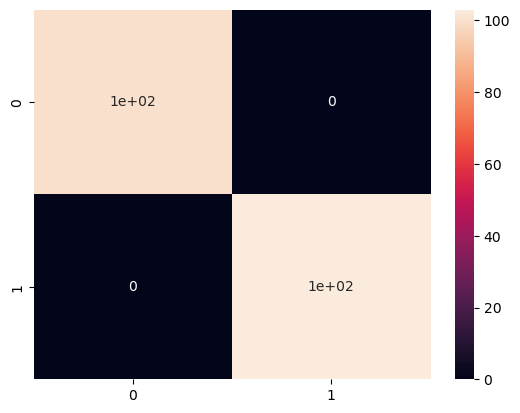

In [23]:
# see confusion matrix using heatmap
sns.heatmap(cm,annot=True)
plt.show()

#convert model into file to use another file

In [24]:
joblib.dump(models["Decision Tree"],"heart.joblib")

['heart.joblib']